In [1]:
import pandas as pd
import numpy as np
import torch

# 1. Carga dos Dados Limpos e Cronológicos do Notebook 01
# Estes ficheiros já respeitam o isolamento temporal (Treino nas sessões 1-6 e Teste nas 7-8)
df_train = pd.read_csv('../data/train_keystroke.csv')
df_test = pd.read_csv('../data/test_keystroke.csv')

# 2. Motor Avançado de Pareamento Siamês com Regularização Temporal
def gerar_pares_siameses_robustos(df, aplicar_ruido=False):
    pares_features = [] # Armazena os pares [Digitação Âncora, Digitação Comparada]
    pares_labels = []   # Armazena 1 (Mesmo utilizador) ou 0 (Impostor)

    # Agrupamento por utilizador para gerir os sorteios intra-classe e inter-classe
    agrupado = df.groupby('subject')
    lista_utilizadores = list(agrupado.groups.keys())

    for utilizador, grupo in agrupado:
        # Extraímos apenas a matriz de features temporais (21 colunas)
        features = grupo.drop('subject', axis=1).values
        n_amostras = len(features)

        for i in range(n_amostras):
            # --- CRIANDO UM PAR POSITIVO (Label 1) ---
            # Sorteamos outra linha aleatória do mesmo utilizador
            idx_positivo = np.random.choice(n_amostras)
            amostra_ancora = features[i]
            amostra_positiva = features[idx_positivo]

            # DATA AUGMENTATION: Vacina matemática contra o Template Drift
            # Adiciona ruído gaussiano controlado em 50% das amostras de treino
            if aplicar_ruido and np.random.rand() > 0.5:
                # Média 0 e desvio padrão de 0.05 (ajuste fino nas frações de milissegundo)
                ruido = np.random.normal(loc=0.0, scale=0.05, size=amostra_positiva.shape)
                amostra_positiva = amostra_positiva + ruido

            pares_features.append([amostra_ancora, amostra_positiva])
            pares_labels.append(1)

            # --- CRIANDO UM PAR NEGATIVO (Label 0) ---
            # Sorteamos um utilizador diferente e uma amostra dele (Tentativa de Fraude)
            utilizador_negativo = np.random.choice([u for u in lista_utilizadores if u != utilizador])
            grupo_negativo = agrupado.get_group(utilizador_negativo).drop('subject', axis=1).values
            idx_negativo = np.random.choice(len(grupo_negativo))

            pares_features.append([amostra_ancora, grupo_negativo[idx_negativo]])
            pares_labels.append(0)

    return np.array(pares_features), np.array(pares_labels)

print("=== FASE 1: GERAÇÃO DE PARES BIOMÉTRICOS ===")
print("Gerando pares de Treino com Data Augmentation 1D...")
X_train_pairs, y_train_labels = gerar_pares_siameses_robustos(df_train, aplicar_ruido=True)

print("Gerando pares de Teste completamente cegos (Mundo Real)...")
X_test_pairs, y_test_labels = gerar_pares_siameses_robustos(df_test, aplicar_ruido=False)

# 3. Conversão para Estruturas de Tensores do PyTorch
tensor_X_train = torch.tensor(X_train_pairs, dtype=torch.float32)
tensor_y_train = torch.tensor(y_train_labels, dtype=torch.float32)

tensor_X_test = torch.tensor(X_test_pairs, dtype=torch.float32)
tensor_y_test = torch.tensor(y_test_labels, dtype=torch.float32)

print("\n=== FASE 2: DIMENSÕES MATRICIAIS DOS TENSORES ===")
print(f"Formato X_train: {tensor_X_train.shape} (Pares, Elementos do Par, Número de Features)")
print(f"Formato y_train: {tensor_y_train.shape}")
print(f"Formato X_test: {tensor_X_test.shape}")

=== FASE 1: GERAÇÃO DE PARES BIOMÉTRICOS ===
Gerando pares de Treino com Data Augmentation 1D...
Gerando pares de Teste completamente cegos (Mundo Real)...

=== FASE 2: DIMENSÕES MATRICIAIS DOS TENSORES ===
Formato X_train: torch.Size([23372, 2, 21]) (Pares, Elementos do Par, Número de Features)
Formato y_train: torch.Size([23372])
Formato X_test: torch.Size([8324, 2, 21])



=== FASE 2.5: VALIDAÇÃO VISUAL DO PRE-PROCESSAMENTO ===


C:\Users\luizm\AppData\Local\Temp\ipykernel_9444\2069824443.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Fraudes (0)', 'Autênticos (1)'], y=contagens, palette=['coral', 'teal'], ax=axes[0])


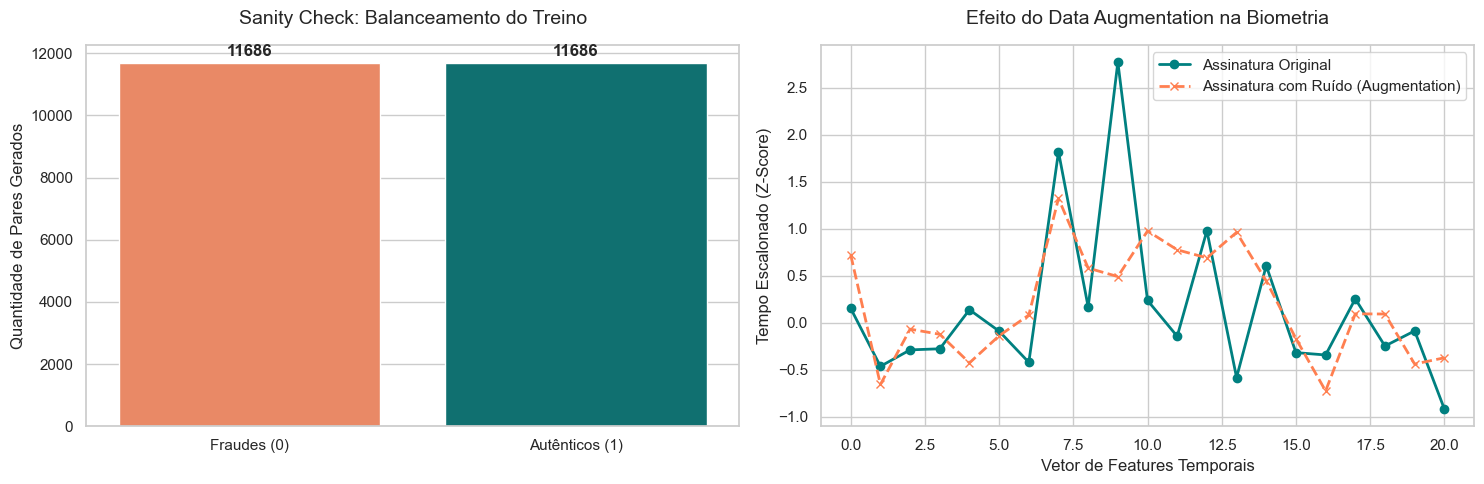

Validação concluída: As classes estão perfeitamente balanceadas e o ruído sintético mantém a geometria do ritmo.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n=== FASE 2.5: VALIDAÇÃO VISUAL DO PRE-PROCESSAMENTO ===")

# Configuração minimalista para a apresentação
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- GRÁFICO 1: Prova de Balanceamento de Classes ---
# Contando a distribuição de labels no conjunto de treino
labels_treino = tensor_y_train.numpy()
unicos, contagens = np.unique(labels_treino, return_counts=True)

sns.barplot(x=['Fraudes (0)', 'Autênticos (1)'], y=contagens, palette=['coral', 'teal'], ax=axes[0])
axes[0].set_title("Sanity Check: Balanceamento do Treino", fontsize=14, pad=15)
axes[0].set_ylabel("Quantidade de Pares Gerados", fontsize=12)

# Adicionando os números exatos em cima das barras para clareza absoluta
for i, v in enumerate(contagens):
    axes[0].text(i, v + (max(contagens)*0.02), str(v), ha='center', fontsize=12, fontweight='bold')


# --- GRÁFICO 2: A Prova do Data Augmentation 1D ---
# Vamos buscar o primeiro par positivo gerado (Label == 1)
indice_exemplo = np.where(labels_treino == 1)[0][0]
assinatura_ancora = tensor_X_train[indice_exemplo, 0, :].numpy()
assinatura_ruido = tensor_X_train[indice_exemplo, 1, :].numpy()

# Eixo X representando as 21 features temporais extraídas
eixo_x = np.arange(len(assinatura_ancora))

axes[1].plot(eixo_x, assinatura_ancora, label='Assinatura Original', color='teal', linewidth=2, marker='o')
axes[1].plot(eixo_x, assinatura_ruido, label='Assinatura com Ruído (Augmentation)', color='coral', linewidth=2, linestyle='--', marker='x')

axes[1].set_title("Efeito do Data Augmentation na Biometria", fontsize=14, pad=15)
axes[1].set_xlabel("Vetor de Features Temporais", fontsize=12)
axes[1].set_ylabel("Tempo Escalonado (Z-Score)", fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

print("Validação concluída: As classes estão perfeitamente balanceadas e o ruído sintético mantém a geometria do ritmo.")

In [3]:
from torch.utils.data import TensorDataset, DataLoader
import os

# --- FASE 3: CRIANDO O MOTOR DE INJEÇÃO EM LOTES (DATALOADERS) ---

# 1. Empacotando tensores num objeto estruturado Dataset
train_dataset = TensorDataset(tensor_X_train, tensor_y_train)
test_dataset = TensorDataset(tensor_X_test, tensor_y_test)

# 2. Definição do Tamanho do Lote (Otimizado para BatchNorm1d)
BATCH_SIZE = 128

# 3. Instanciação dos DataLoaders do PyTorch
# shuffle=True garante o embaralhamento aleatório a cada época para evitar caminhos cíclicos de gradiente
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("=== FASE 3: CONFIGURAÇÃO DOS DATALOADERS ===")
print(f"Tamanho do lote definido: {BATCH_SIZE} amostras por iteração")
print(f"Total de lotes de Treino (Pulsos por Época): {len(train_loader)}")
print(f"Total de lotes de Teste: {len(test_loader)}")


# --- FASE 4: CONGELAMENTO E PERSISTÊNCIA EM DISCO ---
# Salvando as matrizes finais prontas para o ecossistema de Deep Learning
os.makedirs('../data', exist_ok=True)

torch.save(tensor_X_train, '../data/tensor_X_train.pt')
torch.save(tensor_y_train, '../data/tensor_y_train.pt')
torch.save(tensor_X_test, '../data/tensor_X_test.pt')
torch.save(tensor_y_test, '../data/tensor_y_test.pt')

print("\n=== FASE 4: EXPORTAÇÃO COMPLETA ===")
print("Tensores guardados como ficheiros binários '.pt' na pasta 'data/'.")
print("O Pipeline de Pre-Processamento e Tensores foi concluído com sucesso e sem vazamento de dados.")

=== FASE 3: CONFIGURAÇÃO DOS DATALOADERS ===
Tamanho do lote definido: 128 amostras por iteração
Total de lotes de Treino (Pulsos por Época): 183
Total de lotes de Teste: 66

=== FASE 4: EXPORTAÇÃO COMPLETA ===
Tensores guardados como ficheiros binários '.pt' na pasta 'data/'.
O Pipeline de Pre-Processamento e Tensores foi concluído com sucesso e sem vazamento de dados.
